<a href="https://colab.research.google.com/github/muhammadrizki2001/DataScience_240401010030_Muhammad-Rizki/blob/main/Pertemuan13_Muhammad_Rizki_240401010030.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

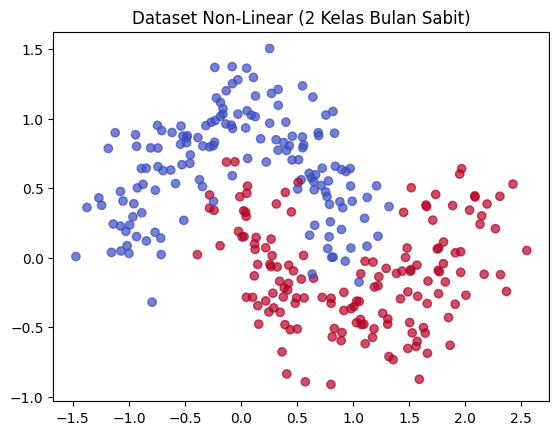

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()
# Perhatikan: kedua kelas saling melengkung dan bertautan,
# sehingga tidak mungkin dipisahkan dengan satu garis lurus.

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42)
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
     ])
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()
history = model.fit(X_tr, y_tr, epochs=30,
                    validation_split=0.2, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Akurasi pada data uji: 0.883


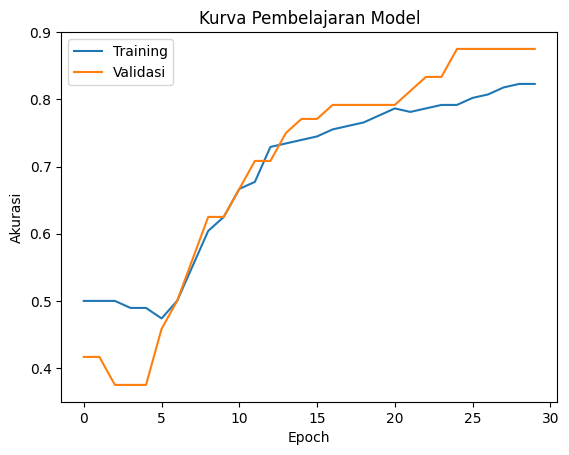

In [ ]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.show()

# Interpretasikan dalam sel Markdown:
# Apakah akurasi training & validasi saling mendekat (baik),
# atau saling menjauh (indikasi overfitting)?

## JAWABAN:
Berdasarkan kurva bisa dilihat bahwa kurva training dan validasi terpisah jauh (epoch 0-5), kemudian saling mendekat dan kovergen di rentang epoch 10-30. Dan pada fase akhir pelatihan (epoch 21 - 30), akurasi validasi bahkan melampaui akurasi training. Kondisi ini tidak menunjukkan overfitting karena overfitting ditandai dengan akurasi training yang jauh lebih tinggi ketimbang akurasi validasi. Kasus validasi yang diatas training bisa terjadi akibat penggunaan teknik regularisasi seperti Dropout. Secara keseluruhan, kurva ini menunjukkan model belajar baik (good fit) karena kurva konvergen dan tidak saling menjauh.

In [ ]:
ulasan = [
    # === POSITIF (1) ===
    'Barangnya bagus banget, pengiriman cepat',          # 1
    'Sangat puas, akan beli lagi',                       # 2
    'Recommended, harga sesuai kualitas',                # 3
    'Produk original, packagingnya rapi sekali',          # 4
    'Seller ramah, respon cepat, barang oke',            # 5
    'Kualitas premium, jauh melebihi ekspektasi',        # 6
    'Pengiriman sangat cepat, tidak sampai sehari',      # 7
    'Mantap, sudah order ketiga kalinya, selalu memuaskan', # 8
    'Barang sesuai foto, warna persis sama',              # 9
    'Toko terpercaya, barang asli dan berkualitas',       # 10
    'Sangat worth it, puas banget sama produknya',       # 11
    'Cepat banget nyampenya, aman terbungkus bubble wrap', # 12
    'Barang top, akan rekomendasikan ke teman-teman',    # 13
    'Luar biasa, kualitas jahitannya sangat rapi',        # 14
    'Pengiriman kilat, barang tidak cacat sedikitpun',   # 15
    'Produk bagus, harga bersaing, penjual profesional',  # 16
    'Keren banget, persis seperti yang diiklankan',      # 17
    'Suka banget, materialnya nyaman dipakai',           # 18
    'Bintang lima! Tidak mengecewakan sama sekali',      # 19
    'Responsif, fast respon, barang dikirim hari itu juga', # 20

    # === NEGATIF (0) ===
    'Kualitas jelek, tidak sesuai deskripsi',            # 21
    'Kecewa, barang rusak saat sampai',                  # 22
    'Buruk sekali, tidak sesuai ekspektasi',             # 23
    'Barang tidak sesuai foto, warna berbeda jauh',      # 24
    'Pengiriman lambat, sudah dua minggu belum sampai',  # 25
    'Penjual tidak responsif, susah dihubungi',          # 26
    'Barang palsu, bukan original seperti yang dijanjikan', # 27
    'Sangat mengecewakan, packaging asal-asalan',        # 28
    'Tidak rekomendasikan, banyak cacat produksi',       # 29
    'Mahal tapi kualitas murahan, rugi beli disini',     # 30
    'Bau tidak sedap saat dibuka, tidak higienis',       # 31
    'Ukuran tidak sesuai yang tertulis di deskripsi',    # 32
    'Barang datang dalam kondisi penyok dan pecah',      # 33
    'Komplain tidak ditanggapi, pelayanan buruk',        # 34
    'Sudah bayar tapi barang tidak kunjung dikirim',     # 35
    'Kualitas sangat jauh dari harga yang dibayarkan',   # 36
    'Zonk! Gambar menarik tapi barang aslinya murahan',  # 37
    'Tidak sesuai spesifikasi, bahan tipis dan mudah robek', # 38
    'Penjual tidak jujur, deskripsi sangat menyesatkan', # 39
    'Kecewa berat, ini pembelian terburuk yang pernah ada', # 40
]

label = [
    # Positif
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    # Negatif
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)
print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 147
['ada' 'akan' 'aman' 'asal' 'asalan' 'asli' 'aslinya' 'bagus' 'bahan'
 'banget']


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42)
model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)
akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')
kalimat_baru = ['Bau tidak sedap saat dibuka, tidak higienis']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.500
Negatif
